# ጒ Lab 37: Feature Engineering and Cross-Validation

## ጒ Purpose

In this lab, you will learn how to improve machine learning models by creating better features, encoding categorical variables correctly, validating models with cross-validation, tuning model hyperparameters, and building full preprocessing pipelines.

You will work with a realistic **synthetic e-commerce dataset** and predict **total sales** using multiple feature engineering strategies and regression models.

This lab has been adapted for **Google Colab**, so every step is notebook-friendly and directly runnable.

## ጒ Learning Objectives

By the end of this lab, students will be able to:

* Create new features from existing data including date/time features, groupings, and ratios.
* Apply one-hot encoding to categorical variables using `scikit-learn`.
* Implement cross-validation using `cross_val_score()`.
* Perform hyperparameter tuning with `GridSearchCV`.
* Understand why feature engineering improves machine learning workflows.
* Evaluate model performance using proper cross-validation techniques.
* Build a full preprocessing and modeling pipeline using `Pipeline` and `ColumnTransformer`.

## ጒ Prerequisites

Before starting this lab, students should have:
* Basic understanding of Python and `pandas`.
* Familiarity with `scikit-learn` and machine learning concepts (train/test splits).
* Experience using Google Colab.

## ⚙️ Google Colab Environment Setup

This lab is designed for **Google Colab**. All shell commands use `!` and plots will display inline.

## ጒ Task 1: Environment Setup and Data Loading

### ELI10
Before building anything, we make sure our notebook has the right tools. This is like laying out all the ingredients before cooking.

In [1]:
!pip -q install pandas numpy scikit-learn matplotlib seaborn

In [2]:
import pandas as pd
import numpy as np
from datetime import datetime, timedelta
import matplotlib.pyplot as plt
import seaborn as sns
import os

# Scikit-learn imports
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV, KFold, TimeSeriesSplit, cross_validate
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

# Reproducibility and display settings
np.random.seed(42)
pd.set_option("display.max_columns", None)
sns.set_theme(style="whitegrid")

print("All libraries are ready!")

All libraries are ready!


In [3]:
def create_sample_data(n_samples=1000):
    # Generate dates for 2023
    start_date = datetime(2023, 1, 1)
    end_date = datetime(2023, 12, 31)
    date_range = pd.date_range(start=start_date, end=end_date, freq='D')

    data = {
        'order_date': np.random.choice(date_range, n_samples),
        'customer_age': np.random.randint(18, 80, n_samples),
        'product_category': np.random.choice(['Electronics', 'Clothing', 'Books', 'Home', 'Sports'], n_samples),
        'customer_type': np.random.choice(['New', 'Returning', 'Premium'], n_samples),
        'quantity': np.random.randint(1, 10, n_samples),
        'unit_price': np.random.uniform(10, 500, n_samples),
        'shipping_cost': np.random.uniform(5, 50, n_samples),
        'discount_percent': np.random.uniform(0, 30, n_samples),
        'customer_satisfaction': np.random.randint(1, 6, n_samples)
    }

    df = pd.DataFrame(data)

    # Calculate target: total_sales
    df['total_sales'] = df['quantity'] * df['unit_price'] * (1 - df['discount_percent']/100) + df['shipping_cost']

    # Add noise and clip
    df['total_sales'] += np.random.normal(0, 10, n_samples)
    df['total_sales'] = df['total_sales'].clip(lower=1)

    # Sort and reset
    df = df.sort_values('order_date').reset_index(drop=True)
    return df

df = create_sample_data()
df.to_csv('feature_engineering_dataset.csv', index=False)
print(f"Dataset shape: {df.shape}")
display(df.head())

Dataset shape: (1000, 10)


,order_date,customer_age,product_category,customer_type,quantity,unit_price,shipping_cost,discount_percent,customer_satisfaction,total_sales
0,2023-01-01,22,Books,Premium,2,393.388648,42.872990,3.442259,1,795.367481
1,2023-01-01,59,Electronics,New,1,327.634400,18.089458,29.442643,2,255.895089
2,2023-01-01,62,Home,Returning,2,385.598385,34.760421,19.521732,4,643.328634
3,2023-01-01,69,Books,Returning,7,298.120227,48.233584,12.531257,2,1860.358767
4,2023-01-01,46,Books,Premium,7,467.926502,6.797659,26.451269,4,2422.827336


## ጒ Task 2: Feature Engineering — Creating New Features

### ELI10
Raw data often hides useful patterns. Feature engineering means turning one column into many smarter columns so the model can understand the data better.

In [4]:
def create_datetime_features(df, date_column):
    df_copy = df.copy()
    df_copy[date_column] = pd.to_datetime(df_copy[date_column])
    df_copy['year'] = df_copy[date_column].dt.year
    df_copy['month'] = df_copy[date_column].dt.month
    df_copy['day'] = df_copy[date_column].dt.day
    df_copy['day_of_week'] = df_copy[date_column].dt.dayofweek
    df_copy['day_of_year'] = df_copy[date_column].dt.dayofyear
    df_copy['week_of_year'] = df_copy[date_column].dt.isocalendar().week.astype(int)
    df_copy['is_weekend'] = (df_copy['day_of_week'] >= 5).astype(int)
    df_copy['quarter'] = df_copy[date_column].dt.quarter

    season_map = {12:'Winter', 1:'Winter', 2:'Winter', 3:'Spring', 4:'Spring', 5:'Spring', 6:'Summer', 7:'Summer', 8:'Summer', 9:'Fall', 10:'Fall', 11:'Fall'}
    df_copy['season'] = df_copy['month'].map(season_map)
    df_copy['is_holiday_season'] = df_copy['month'].isin([11, 12]).astype(int)
    return df_copy

df_engineered = create_datetime_features(df, 'order_date')
display(df_engineered[['order_date', 'season', 'is_weekend']].head())

,order_date,season,is_weekend
0,2023-01-01,Winter,1
1,2023-01-01,Winter,1
2,2023-01-01,Winter,1
3,2023-01-01,Winter,1
4,2023-01-01,Winter,1


In [5]:
def create_ratio_features(df):
    df_copy = df.copy()
    df_copy['price_per_unit'] = df_copy['unit_price'] # Renaming for clarity
    df_copy['discount_amount'] = df_copy['unit_price'] * (df_copy['discount_percent']/100)
    df_copy['final_unit_price'] = df_copy['unit_price'] - df_copy['discount_amount']
    df_copy['shipping_to_price_ratio'] = df_copy['shipping_cost'] / df_copy['unit_price']
    df_copy['shipping_per_item'] = df_copy['shipping_cost'] / df_copy['quantity']
    df_copy['order_value_before_shipping'] = df_copy['quantity'] * df_copy['final_unit_price']
    df_copy['avg_item_value'] = df_copy['order_value_before_shipping'] / df_copy['quantity']

    df_copy['age_group'] = pd.cut(df_copy['customer_age'], bins=[0,25,35,50,65,100], labels=["Young","Adult","Middle","Senior","Elder"])
    df_copy['quantity_category'] = pd.cut(df_copy['quantity'], bins=[0,2,5,10], labels=["Low","Medium","High"])
    return df_copy

df_engineered = create_ratio_features(df_engineered)
display(df_engineered[['age_group', 'shipping_to_price_ratio']].head())

,age_group,shipping_to_price_ratio
0,Young,0.108984
1,Senior,0.055212
2,Senior,0.090147
3,Elder,0.161792
4,Middle,0.014527


### Note on Data Leakage
In the next step, we create grouping features. It is critical to use only **predictor** variables (like `unit_price` or `quantity`) and NOT the target variable (`total_sales`) to calculate these stats. Using the target would create leakage, making the model look better than it actually is.

In [6]:
def create_grouping_features(df):
    df_copy = df.copy()
    # Grouping by product category
    cat_stats = df_copy.groupby('product_category')['unit_price'].agg(['mean', 'std']).rename(columns={'mean':'category_avg_price', 'std':'category_price_std'})
    df_copy = df_copy.merge(cat_stats, on='product_category', how='left')

    # Grouping by customer type
    cust_stats = df_copy.groupby('customer_type').agg(
        customer_type_avg_quantity=('quantity', 'mean'),
        customer_type_avg_discount=('discount_percent', 'mean'),
        customer_type_avg_satisfaction=('customer_satisfaction', 'mean')
    )
    df_copy = df_copy.merge(cust_stats, on='customer_type', how='left')

    # Monthly averages
    month_stats = df_copy.groupby('month').agg(
        monthly_avg_unit_price=('unit_price', 'mean'),
        monthly_avg_shipping=('shipping_cost', 'mean'),
        monthly_avg_quantity=('quantity', 'mean')
    )
    df_copy = df_copy.merge(month_stats, on='month', how='left')

    # Relative features
    df_copy['price_vs_category_avg'] = df_copy['unit_price'] - df_copy['category_avg_price']
    df_copy['price_zscore_in_category'] = ((df_copy['unit_price'] - df_copy['category_avg_price']) / df_copy['category_price_std']).fillna(0)
    df_copy['quantity_vs_customer_type_avg'] = df_copy['quantity'] - df_copy['customer_type_avg_quantity']

    return df_copy

df_engineered = create_grouping_features(df_engineered)
display(df_engineered[['product_category', 'price_zscore_in_category']].head())

,product_category,price_zscore_in_category
0,Books,1.019541
1,Electronics,0.618422
2,Home,0.999514
3,Books,0.377972
4,Books,1.521504


## ጒ Task 3: Categorical Variable Encoding

### ELI10
Machine learning models speak the language of numbers. If we have categories like "Electronics", we turn them into 1s and 0s so the model can read them.

In [7]:
cat_cols = df_engineered.select_dtypes(include=["object", "category"]).columns
print("Categorical Columns:")
for col in cat_cols:
    print(f"{col}: {df_engineered[col].nunique()} unique values - {df_engineered[col].unique()}")

Categorical Columns:
product_category: 5 unique values - ['Books' 'Electronics' 'Home' 'Clothing' 'Sports']
customer_type: 3 unique values - ['Premium' 'New' 'Returning']
season: 4 unique values - ['Winter' 'Spring' 'Summer' 'Fall']
age_group: 5 unique values - ['Young', 'Senior', 'Elder', 'Middle', 'Adult']
Categories (5, object): ['Young' < 'Adult' < 'Middle' < 'Senior' < 'Elder']
quantity_category: 3 unique values - ['Low', 'High', 'Medium']
Categories (3, object): ['Low' < 'Medium' < 'High']


In [8]:
def apply_one_hot_encoding(df, categorical_cols, drop_first=True):
    # Note: sparse_output=False is for newer sklearn; use sparse=False for older versions
    encoder = OneHotEncoder(drop='first' if drop_first else None, handle_unknown='ignore', sparse_output=False)
    encoded_data = encoder.fit_transform(df[categorical_cols])
    feature_names = encoder.get_feature_names_out(categorical_cols)
    encoded_df = pd.DataFrame(encoded_data, columns=feature_names, index=df.index)

    final_df = pd.concat([df.drop(columns=categorical_cols), encoded_df], axis=1)
    return final_df, encoder

df_encoded, encoder_obj = apply_one_hot_encoding(df_engineered, cat_cols)
print(f"Original shape: {df_engineered.shape}, Encoded shape: {df_encoded.shape}")

Original shape: (1000, 40), Encoded shape: (1000, 50)


## ጒ Task 4: Cross-Validation Implementation

### ELI10
Instead of testing our model once, we test it several times on different slices of data. This makes sure our model is consistently good and wasn't just "lucky" on one test set.

In [9]:
def prepare_modeling_data(df):
    X = df.drop(columns=['order_date', 'total_sales']).select_dtypes(include=[np.number])
    y = df['total_sales']
    return X, y

X, y = prepare_modeling_data(df_encoded)
print(f"Features: {X.shape[1]}, Samples: {X.shape[0]}")

Features: 48, Samples: 1000


In [10]:
def perform_cross_validation(X, y, model, cv_folds=5):
    kf = KFold(n_splits=cv_folds, shuffle=True, random_state=42)
    mse_scores = cross_val_score(model, X, y, cv=kf, scoring='neg_mean_squared_error')
    r2_scores = cross_val_score(model, X, y, cv=kf, scoring='r2')
    rmse_scores = np.sqrt(-mse_scores)

    print(f"--- {type(model).__name__} ---")
    print(f"Mean RMSE: {rmse_scores.mean():.4f} (+/- {rmse_scores.std()*2:.4f})")
    print(f"Mean R2: {r2_scores.mean():.4f} (+/- {r2_scores.std()*2:.4f})")
    return rmse_scores, r2_scores

results = {}
results['LR'] = perform_cross_validation(X, y, LinearRegression())
results['RF'] = perform_cross_validation(X, y, RandomForestRegressor(n_estimators=100, random_state=42))

--- LinearRegression ---
Mean RMSE: 10.5369 (+/- 1.0368)
Mean R2: 0.9999 (+/- 0.0000)
--- RandomForestRegressor ---
Mean RMSE: 22.4912 (+/- 9.1909)
Mean R2: 0.9993 (+/- 0.0005)


## ጒ Task 5: Hyperparameter Tuning with GridSearchCV

### ELI10
Hyperparameters are like the "knobs" on a machine. We use a grid search to automatically turn these knobs until we find the perfect settings for our model.

In [11]:
param_grid = {
    "n_estimators": [50, 100, 200],
    "max_depth": [None, 10, 20],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 4]
}

grid_search = GridSearchCV(RandomForestRegressor(random_state=42), param_grid, cv=5, scoring='neg_mean_squared_error', n_jobs=-1, verbose=1, return_train_score=True)
grid_search.fit(X, y)

print(f"Best Params: {grid_search.best_params_}")
print(f"Best RMSE: {np.sqrt(-grid_search.best_score_):.4f}")

Fitting 5 folds for each of 81 candidates, totalling 405 fits
Best Params: {'max_depth': None, 'min_samples_leaf': 2, 'min_samples_split': 5, 'n_estimators': 100}
Best RMSE: 21.9813


## ጒ Task 6: Pipeline Creation and Validation

### ELI10
A pipeline is like a factory assembly line. We feed in raw data at one end, and it gets scaled, encoded, and predicted automatically at the other end.

In [12]:
def create_ml_pipeline(df):
    # Re-use engineered data before manual encoding
    X_p = df.drop(columns=['order_date', 'total_sales'])
    y_p = df['total_sales']

    num_cols = X_p.select_dtypes(include=[np.number]).columns
    cat_cols = X_p.select_dtypes(include=['object', 'category']).columns

    preprocessor = ColumnTransformer(transformers=[
        ('num', StandardScaler(), num_cols),
        ('cat', OneHotEncoder(drop='first', handle_unknown='ignore', sparse_output=False), cat_cols)
    ])

    pipeline = Pipeline(steps=[
        ('preprocessor', preprocessor),
        ('regressor', RandomForestRegressor(random_state=42))
    ])

    return pipeline, X_p, y_p

pipe, X_pipe, y_pipe = create_ml_pipeline(df_engineered)
print("Pipeline Steps:", [step[0] for step in pipe.steps])

Pipeline Steps: ['preprocessor', 'regressor']


## ጒ Task 7: Model Evaluation and Interpretation

### ELI10
Now we look at our results. Did we overfit? Which factors were most important for predicting sales?

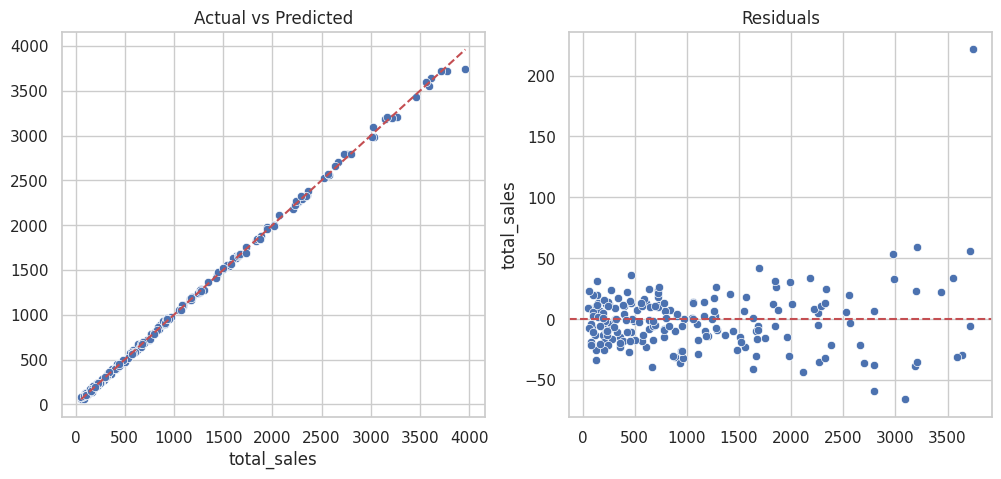

Final Test RMSE: 25.5591
Final Test R2: 0.9993


In [13]:
X_train, X_test, y_train, y_test = train_test_split(X_pipe, y_pipe, test_size=0.2, random_state=42)
pipe.fit(X_train, y_train)

y_pred = pipe.predict(X_test)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
sns.scatterplot(x=y_test, y=y_pred)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
plt.title("Actual vs Predicted")

plt.subplot(1, 2, 2)
sns.scatterplot(x=y_pred, y=y_test-y_pred)
plt.axhline(0, color='r', linestyle='--')
plt.title("Residuals")
plt.savefig('final_model_evaluation.png')
plt.show()

print(f"Final Test RMSE: {rmse:.4f}")
print(f"Final Test R2: {r2:.4f}")

## ✅ Verification Checklist

Before finishing, ensure your notebook has successfully completed these milestones:
- [ ] **Environment Setup**: All libraries installed and imported.
- [ ] **Data Generation**: `feature_engineering_dataset.csv` created and loaded.
- [ ] **Feature Engineering**: Datetime, ratio, and grouping features (leakage-safe) generated.
- [ ] **Encoding**: Categorical variables transformed via One-Hot Encoding.
- [ ] **Validation**: Cross-validation performed on Linear Regression and Random Forest models.
- [ ] **Tuning**: Hyperparameters optimized using `GridSearchCV`.
- [ ] **Pipeline**: Preprocessing and modeling combined into a single `Pipeline` object.
- [ ] **Evaluation**: Final model results visualized with Actual vs. Predicted and Residual plots.

## ጒ Task 8: Troubleshooting Common Issues

### ELI10
Sometimes things don't go as planned. Here is how to fix common hiccups.

*   **AttributeError: 'OneHotEncoder' object has no attribute 'sparse_output'**: This happens on older `scikit-learn` versions. Use `sparse=False` instead of `sparse_output=False`.
*   **Grid Search is too slow**: Reduce the number of parameters in `param_grid` or lower the `cv` value (e.g., `cv=3`).
*   **Plots are not appearing**: Ensure you have imported `matplotlib.pyplot` and called `plt.show()`.
*   **Data Leakage Errors**: If your model accuracy is too good to be true (e.g., 1.0 R²), double-check that you didn't accidentally include `total_sales` when calculating grouping features.

## ጒ Key Concepts Learned

### ጒ Feature Engineering
Turning raw data into smarter indicators. We learned to extract time patterns, calculate price ratios, and compare individual items to category averages.

### ጒ Cross-Validation
Testing the model on multiple "folds" of data to ensure the performance is consistent and not just a result of a lucky split.

### ጒ Hyperparameter Tuning
Using `GridSearchCV` to automatically find the best settings (knobs) for our machine learning algorithm.

### ጒ ML Pipelines
A professional way to bundle data cleaning and modeling together, ensuring that our test data is treated exactly like our training data.

## ጒ Real-World Importance

In industry, these techniques are used every day:
*   **E-commerce**: Predicting sales trends based on holidays and product categories.
*   **Finance**: Creating features to detect fraudulent transactions based on spending ratios.
*   **Healthcare**: Engineering patient features to predict risk scores while using cross-validation to ensure model reliability across different hospitals.
*   **Marketing**: Segmenting customers by age group and behavior to predict future spending.

# ጒ Conclusion

Congratulations! You have successfully built a professional machine learning workflow. You've moved beyond simple model fitting to **architecting** data through feature engineering and ensuring **robustness** through pipelines and cross-validation.

**Lab Completed Successfully!**